This notebook operationalises the concept of “textual attention” within a corpus of critical writing on Alexis Wright. The term is used to describe the extent to which particular theorists are not only cited, but actively mobilised as interpretive frameworks in the analysis of Wright’s work.

The study proceeds from the premise that citation alone is an insufficient indicator of intellectual influence. Bibliographies record presence, but they do not capture the distribution, intensity, or functional role of theoretical engagement within the body of a text. Accordingly, this notebook seeks to measure how attention is allocated across competing theoretical frames, and to distinguish between peripheral reference and sustained interpretive reliance.

Two primary research objectives guide the analysis. First, to identify the key theorists through whom Wright’s work is most frequently interpreted. Second, to quantify the degree of textual attention afforded to these figures, thereby establishing a comparative measure of their interpretive prominence.

Methodologically, the notebook combines corpus processing with frequency-based and positional analysis. Mentions of theorists are detected across the full text of each document, and weighted according to their distribution and recurrence. This enables a more nuanced account of critical engagement, capturing not only who is cited, but how substantially their frameworks shape scholarly readings of Wright’s fiction.


In [1]:
import os
import re
from collections import Counter, defaultdict

import pandas as pd
import matplotlib.pyplot as plt
import spacy

In [2]:
import spacy

nlp = spacy.load("en_core_web_trf")

In [3]:
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "data" / "processed"

if not DATA_DIR.exists():
    raise FileNotFoundError(f"Data directory not found: {DATA_DIR}")

documents = {}

for file in sorted(DATA_DIR.glob("*.txt")):
    text = file.read_text(encoding="utf-8").strip()
    if text:
        documents[file.stem] = text
    else:
        print(f"Skipping empty file: {file.name}")

print(f"Loaded {len(documents)} non-empty documents from {DATA_DIR}")

if not documents:
    raise ValueError("No documents were loaded. Check your data path and file contents.")

Loaded 101 non-empty documents from /Users/FMOR/Documents/GitHub/citational_refusal/data/processed


In [4]:
list(documents.keys())[:5]

["01 Sep 2007 - Australian Women's Book Review: Online - Trove",
 '2006-01-01__ferrier-carole__australian-womens-book-review__the-best-australian-novel-for-years__book-review',
 '2006-08-19__ravenscroft-alison__the-age__when-the-narrators-art-matches-the-magical-storytelling__book-review',
 '2006-09-02__anonymous__the-canberra-times__calming-influence-in-balance-fraught-with-pain__book-review',
 '2006-09-09__osullivan-jane__the-age__from-here-to-carpentaria__book-review']

In [5]:
doc_names = list(documents.keys())
doc_texts = list(documents.values())

processed_docs = []

total_docs = len(doc_texts)
print(f"Starting NER over {total_docs} documents...")

for i, doc in enumerate(nlp.pipe(doc_texts, batch_size=4), start=1):
    processed_docs.append(doc)

    if i % 5 == 0 or i == total_docs:
        print(f"Processed {i}/{total_docs} documents")

print(f"Finished processing {len(processed_docs)} documents.")

Starting NER over 101 documents...
Processed 5/101 documents
Processed 10/101 documents
Processed 15/101 documents
Processed 20/101 documents
Processed 25/101 documents
Processed 30/101 documents
Processed 35/101 documents
Processed 40/101 documents
Processed 45/101 documents
Processed 50/101 documents
Processed 55/101 documents
Processed 60/101 documents
Processed 65/101 documents
Processed 70/101 documents
Processed 75/101 documents
Processed 80/101 documents
Processed 85/101 documents
Processed 90/101 documents
Processed 95/101 documents
Processed 100/101 documents
Processed 101/101 documents
Finished processing 101 documents.


In [6]:
# Extract PERSON entities from each document
person_entities_by_doc = {}

for doc_name, doc in zip(doc_names, processed_docs):
    people = [ent.text.strip() for ent in doc.ents if ent.label_ == "PERSON"]
    person_entities_by_doc[doc_name] = people

sum(len(v) for v in person_entities_by_doc.values())

19882

In [7]:
sample_doc = doc_names[0]
person_entities_by_doc[sample_doc][:30]

['Alexis Wright',
 'Carole Ferrier',
 'Jaqui Katona',
 'Murrandoo Yanner',
 'Katona',
 'Yanner',
 'Wright',
 'Wright',
 'Eliot',
 'Angel Day',
 'Normal Phantom',
 "Janet Frame's",
 'Angel',
 'Joseph Midnght',
 'Stan Bruiser',
 'Truthful',
 'Bruiser',
 "Vivienne Cleven's",
 "Joseph Midnight's",
 'Midnight',
 'Matthew Flinders',
 'Masterton',
 'Elias',
 'Mozzie Fishman',
 'Norm',
 'Phantom',
 'Angel',
 'Norm',
 'Will',
 'Che Guevara']

Preliminary NER indicates many of the extracted names are characters from the novel. The analysis therefore excludes a defined set of names drawn from Carpentaria, including Normal Phantom, Angel Day, Will Phantom, Kevin Phantom, Mozzie Fishman, Joseph Midnight, Hope, Bala, Elias Smith, Stan Bruiser, Libby Valance, Captain Nicoli Finn, Uncle Micky, A.D. Smith, Sallyanne Smith, Lloydie Smith, Inso, Donny, Janice, Patsy, Girlie, Noelie, Tristum Fishman, Junior Fishman, Aaron Ho Kum, Conte, Chuck, Cookie, and Graham Spilling. These figures are omitted in order to remove narrative characters and locally situated actors from the dataset, thereby preventing the overrepresentation of fictional entities and enabling the analysis to focus more precisely on references to external scholars and interpretive authorities.

In [21]:
# Normalise extarcted names

exclude_names = set([
    "",
    "alexis wright",
    "alexis wrights",
    "alexis wright's",
    "truthful",
    "bala",
    "joseph",
    "molly",
    "bruiser",
    "jasal",
    "wright",
    "fishman",
    "mozzie fishman",
    "bella donna",
    "alexis",
    "alexis wright",
    "wright",
    "norm phantom",
    "mozzie fishman",
    "bobby",
    "max",
    "angel day",
    "danny",
    "phantom",
    "pricklebush",
    "will phantom",
    "joseph midnight",
    "hope",
    "oblivia",
    "carpentaria",
    "norm",
    "ivy",
    "will",
    "alexis",
    "normal",
    "angel",
    "mozzie",
    "will",
    "elias",
    "normal phantom",
    "elias smith",
    "joseph midnight"

])

def normalise_name(name):
    name = name.strip().lower()
    name = re.sub(r"\s+", " ", name)
    name = re.sub(r"[^\w\s\-']", "", name)
    return name

normalised_people_by_doc = {
    doc_name: [
        name for name in (normalise_name(n) for n in names)
        if name and name not in exclude_names
    ]
    for doc_name, names in person_entities_by_doc.items()
}

#flatten names into a list

all_people = [
    name
    for names in normalised_people_by_doc.values()
    for name in names
    if name and name not in exclude_names
]

print(f"Total normalised person mentions: {len(all_people)}")

Total normalised person mentions: 14153


In [22]:
name_counts = Counter(all_people)

top_people_df = pd.DataFrame(
    name_counts.most_common(50),
    columns=["person", "count"]
)

top_people_df.head(20)

,person,count
0,glissant,130
1,scott,126
2,kevin,105
3,ravenscroft,93
4,langton,84
5,miller,57
6,brewster,49
7,alison ravenscroft,45
8,mabo,44
9,rose,42


In [23]:
name_map = {
    "bhabha": "homi bhabha",
    "spivak": "gayatri spivak",
    "foucault": "michel foucault",
    "derrida": "jacques derrida",
    "deleuze": "gilles deleuze",
    "guattari": "félix guattari",
    "butler": "judith butler",
    "ghosh": "amitav ghosh",
    "ravenscroft": "alison ravenscroft",
    "langton": "marcia langton",
    "leane": "jeanine leane",
    "rose": "deborah bird rose",
    "scott": "kim scott",
    "slemon": "stephen slemon",
    "glissant": "edouard glissant",
    "brewster": "anne brewster",
    "flanagan": "richard flanagan",
    "ashcroft": "bill ashcroft",
    "morrison": "toni morrison",
    "herbert": "xavier herbert",
    "leane": "jeanine leane",
    "rose": "deborah bird rose",
    
}

def apply_name_map(name, mapping):
    return mapping.get(name, name)

consolidated_people_by_doc = {
    doc_name: [
        apply_name_map(name, name_map)
        for name in names
        if apply_name_map(name, name_map) not in exclude_names
    ]
    for doc_name, names in normalised_people_by_doc.items()
}

all_consolidated_people = [
    name
    for names in consolidated_people_by_doc.values()
    for name in names
    if name and name not in exclude_names
]

consolidated_counts = Counter(all_consolidated_people)

consolidated_top_people_df = pd.DataFrame(
    consolidated_counts.most_common(50),
    columns=["person", "count"]
)

consolidated_top_people_df.head(25)

,person,count
0,kim scott,164
1,alison ravenscroft,138
2,edouard glissant,136
3,marcia langton,108
4,kevin,105
5,anne brewster,79
6,jeanine leane,61
7,deborah bird rose,57
8,miller,57
9,toni morrison,51


In [24]:
#diagnostic check 
print("alexis" in consolidated_counts)
print("normal" in consolidated_counts)
print("normal phantom" in consolidated_counts)
print(consolidated_counts.most_common(40))

False
False
False
[('kim scott', 164), ('alison ravenscroft', 138), ('edouard glissant', 136), ('marcia langton', 108), ('kevin', 105), ('anne brewster', 79), ('jeanine leane', 61), ('deborah bird rose', 57), ('miller', 57), ('toni morrison', 51), ('richard flanagan', 45), ('mabo', 44), ('xavier herbert', 43), ('homi bhabha', 43), ('stephen slemon', 42), ('bill ashcroft', 41), ('mudrooroo', 38), ('jacques derrida', 38), ('lynda ng', 38), ('michel foucault', 37), ('amitav ghosh', 36), ('oodgeroo', 34), ('brigitta olubas', 33), ('elizabeth', 32), ('gayatri spivak', 32), ('tony simoes da silva', 32), ('anne', 31), ('mary', 30), ('celia', 30), ('félix guattari', 30), ('howard', 29), ('watson', 29), ('harris', 29), ('griffiths', 29), ('takolander', 28), ('gilles deleuze', 28), ('day', 28), ('smith', 27), ('devlin', 27), ('paul', 27)]


In [25]:
candidate_figures = [
    name for name, count in consolidated_counts.most_common(30)
]

print(f"Selected {len(candidate_figures)} candidate figures.")
print(candidate_figures[:20])

if not candidate_figures:
    raise ValueError("No candidate figures found. Check filtering and consolidation steps.")

Selected 30 candidate figures.
['kim scott', 'alison ravenscroft', 'edouard glissant', 'marcia langton', 'kevin', 'anne brewster', 'jeanine leane', 'deborah bird rose', 'miller', 'toni morrison', 'richard flanagan', 'mabo', 'xavier herbert', 'homi bhabha', 'stephen slemon', 'bill ashcroft', 'mudrooroo', 'jacques derrida', 'lynda ng', 'michel foucault']


In [52]:
"""def textual_attention_score(text, person_name):
    pattern = re.compile(r"\b" + re.escape(person_name) + r"\b", re.IGNORECASE)
    matches = list(pattern.finditer(text))
    freq = len(matches)

    if freq == 0:
        return 0.0

    positions = [m.start() for m in matches]

    if freq == 1:
        spread = 1
    else:
        spread = max(positions) - min(positions)

    text_length = max(len(text), 1)
    normalised_spread = spread / text_length

    return freq * normalised_spread"""


import re

def textual_attention_score(text, person_name):
    # --- Step 1: cut off bibliography ---
    cutoff_match = re.search(
        r"^\s*(references|bibliography|works\s+cited)\s*$",
        text,
        re.IGNORECASE | re.MULTILINE
    )
    if cutoff_match:
        text = text[:cutoff_match.start()]

    # --- Step 2: find name occurrences ---
    pattern = re.compile(r"\b" + re.escape(person_name) + r"\b", re.IGNORECASE)
    matches = list(pattern.finditer(text))
    freq = len(matches)

    if freq == 0:
        return 0.0

    positions = [m.start() for m in matches]

    # --- Step 3: compute spread ---
    if freq == 1:
        spread = 1
    else:
        spread = max(positions) - min(positions)

    # --- Step 4: normalise ---
    text_length = max(len(text), 1)
    normalised_spread = spread / text_length

    return freq * normalised_spread

In [53]:
def clean_pdf_text(text):
    text = re.sub(r"\s+", " ", text)
    text = re.sub(r"([a-z])([A-Z])", r"\1 \2", text)
    return text.strip()

def chunk_text(text, chunk_size=2000):
    cleaned = clean_pdf_text(text)
    return [cleaned[i:i+chunk_size] for i in range(0, len(cleaned), chunk_size)]

def chunk_attention_score(text, person_name, chunk_size=2000):
    chunks = chunk_text(text, chunk_size=chunk_size)
    
    if not chunks:
        return 0.0
    
    pattern = re.compile(r"\b" + re.escape(person_name) + r"\b", re.IGNORECASE)
    matching_chunks = sum(1 for chunk in chunks if pattern.search(chunk))
    
    return matching_chunks / len(chunks)

In [54]:
# Compute frequency and attention per document

frequency_results = defaultdict(dict)
spread_attention_results = defaultdict(dict)
chunk_attention_results = defaultdict(dict)

total_docs = len(documents)
print(f"Scoring {total_docs} documents across {len(candidate_figures)} candidate figures...")

for i, (doc_name, text) in enumerate(documents.items(), start=1):
    for person in candidate_figures:
        pattern = re.compile(r"\b" + re.escape(person) + r"\b", re.IGNORECASE)
        matches = list(pattern.finditer(text))

        frequency_results[doc_name][person] = len(matches)
        spread_attention_results[doc_name][person] = textual_attention_score(text, person)
        chunk_attention_results[doc_name][person] = chunk_attention_score(text, person, chunk_size=2000)

    if i % 5 == 0 or i == total_docs:
        print(f"Scored {i}/{total_docs} documents")

print("Finished scoring all documents.")

Scoring 101 documents across 30 candidate figures...
Scored 5/101 documents
Scored 10/101 documents
Scored 15/101 documents
Scored 20/101 documents
Scored 25/101 documents
Scored 30/101 documents
Scored 35/101 documents
Scored 40/101 documents
Scored 45/101 documents
Scored 50/101 documents
Scored 55/101 documents
Scored 60/101 documents
Scored 65/101 documents
Scored 70/101 documents
Scored 75/101 documents
Scored 80/101 documents
Scored 85/101 documents
Scored 90/101 documents
Scored 95/101 documents
Scored 100/101 documents
Scored 101/101 documents
Finished scoring all documents.


In [47]:
# Convert result dictionaries into DataFrames

df_freq = pd.DataFrame.from_dict(frequency_results, orient="index").fillna(0)
df_spread_attention = pd.DataFrame.from_dict(spread_attention_results, orient="index").fillna(0)
df_chunk_attention = pd.DataFrame.from_dict(chunk_attention_results, orient="index").fillna(0)

print("Shapes:")
print("df_freq:", df_freq.shape)
print("df_spread_attention:", df_spread_attention.shape)
print("df_chunk_attention:", df_chunk_attention.shape)

Shapes:
df_freq: (101, 30)
df_spread_attention: (101, 30)
df_chunk_attention: (101, 30)


In [48]:
comparison_df = pd.DataFrame({
    "frequency": df_freq.sum(axis=0),
    "spread_attention": df_spread_attention.sum(axis=0),
    "chunk_attention": df_chunk_attention.sum(axis=0)
}).sort_values(by="chunk_attention", ascending=False)

print(f"Comparison table contains {len(comparison_df)} figures.")
comparison_df.head(20)

Comparison table contains 30 figures.


,frequency,spread_attention,chunk_attention
anne,114,17.036608,3.935884
mary,81,10.614057,2.917389
mabo,114,52.979878,2.870258
kim scott,68,23.585524,2.815720
kevin,137,56.312740,2.701905
mudrooroo,80,18.937270,2.633122
elizabeth,72,11.527941,2.600988
alison ravenscroft,46,20.155396,2.305879
xavier herbert,28,5.689990,2.080205
lynda ng,43,15.810289,1.719382


Chunk attention measures the proportion of fixed-length textual segments in which a given figure is mentioned. By segmenting the text into uniform units, this metric provides a robust approximation of the distribution of interpretive attention, independent of unreliable paragraph or formatting boundaries in PDF-derived corpora.

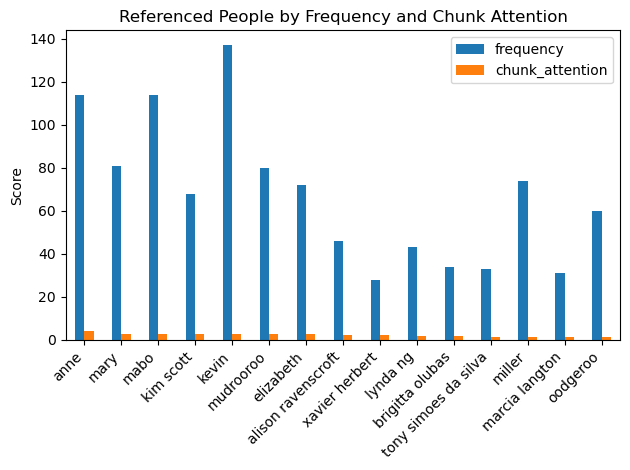

In [49]:
top_n = 15

comparison_df.head(top_n)[["frequency", "chunk_attention"]].plot(kind="bar")
plt.title("Referenced People by Frequency and Chunk Attention")
plt.ylabel("Score")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [50]:
dominant_figures_df = pd.DataFrame({
    "dominant_by_frequency": df_freq.idxmax(axis=1),
    "max_frequency": df_freq.max(axis=1),
    "dominant_by_spread_attention": df_spread_attention.idxmax(axis=1),
    "max_spread_attention": df_spread_attention.max(axis=1),
    "dominant_by_chunk_attention": df_chunk_attention.idxmax(axis=1),
    "max_chunk_attention": df_chunk_attention.max(axis=1),
})

dominant_figures_df.head(20)

,dominant_by_frequency,max_frequency,dominant_by_spread_attention,max_spread_attention,dominant_by_chunk_attention,max_chunk_attention
01 Sep 2007 - Australian Women's Book Review: Online - Trove,kim scott,0,kim scott,0.000000,kim scott,0.000000
2006-01-01__ferrier-carole__australian-womens-book-review__the-best-australian-novel-for-years__book-review,kim scott,0,kim scott,0.000000,kim scott,0.000000
2006-08-19__ravenscroft-alison__the-age__when-the-narrators-art-matches-the-magical-storytelling__book-review,kim scott,0,kim scott,0.000000,alison ravenscroft,0.500000
2006-09-02__anonymous__the-canberra-times__calming-influence-in-balance-fraught-with-pain__book-review,mabo,1,mabo,0.000172,mabo,0.333333
2006-09-09__osullivan-jane__the-age__from-here-to-carpentaria__book-review,kim scott,0,kim scott,0.000000,xavier herbert,0.166667
2006-09-16__davison-liam__the-sydney-morning-herald__phantasmagorical-tale-fills-a-legendary-landscape__book-review,kim scott,0,kim scott,0.000000,alison ravenscroft,0.200000
2006-09-30__england-katherine__the-advertiser__small-town-dreaming__book-review,kim scott,0,kim scott,0.000000,xavier herbert,0.333333
2006-10-01__mcfadyen-kate__australian-book-review__carpentaria-by-alexis-wright__book-review,kim scott,0,kim scott,0.000000,kim scott,0.000000
2006-10-04__grossman-michelle__the-australian__risk-roguery-amd-revelation__book-review,kim scott,0,kim scott,0.000000,kim scott,0.333333
2007-01-01__coles-david__ngoonjook__carpentaria__book-review,xavier herbert,1,xavier herbert,0.000057,xavier herbert,0.111111


In [51]:
output_dir = PROJECT_ROOT / "outputs"
output_dir.mkdir(exist_ok=True)

top_people_df.to_csv(output_dir / "top_people_raw.csv", index=False)
consolidated_top_people_df.to_csv(output_dir / "top_people_consolidated.csv", index=False)

df_freq.to_csv(output_dir / "person_frequency_by_document.csv")
df_spread_attention.to_csv(output_dir / "person_spread_attention_by_document.csv")
df_chunk_attention.to_csv(output_dir / "person_chunk_attention_by_document.csv")

comparison_df.to_csv(output_dir / "person_corpus_comparison.csv")
dominant_figures_df.to_csv(output_dir / "dominant_figures_by_document.csv")

print(f"Saved outputs to {output_dir}")

Saved outputs to /Users/FMOR/Documents/GitHub/citational_refusal/outputs
